# 12 · Contraste pareado del efecto de alcance territorial — Bogotá 2023

**Objetivo.** Estimar directamente el cambio en la brecha mujer–hombre de tiempo medio de primera llegada al pasar de **Bogotá D. C. interno** a **Bogotá–Región**.

Esta es la **Compuerta 13**. Ambos alcances se recalculan con el mismo multiplicador Poisson por hogar en cada réplica. Así, el intervalo de la diferencia incorpora la dependencia entre muestras superpuestas. Los kernels poblacionales y los conjuntos `core_50` permanecen fijos en sus estimaciones puntuales, como en las compuertas anteriores.


In [1]:
%pip -q install pandas pyarrow numpy scipy matplotlib seaborn geopandas networkx


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import csv, hashlib, json, os, re, shutil, unicodedata, zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate13"
OUT = ROOT / "outputs/bogota_em2023/gate13"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
for directory in (RAW, INTERIM, OUT): directory.mkdir(parents=True, exist_ok=True)

SOURCE_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/05_Base%20datos%20procesada%20EODH.zip"
ZONING_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/03_Zonificacion%20EODH%20%281%29.zip"
PURPOSES = ("employment", "education", "health")
EFFECTS = ("female_minus_male_total", "residential_contribution", "kernel_contribution")
TAU = 20.0
BOOTSTRAP_REPLICATES = 500
RANDOM_SEED = 202313

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Entorno fuera de Colab o Drive no montado: {exc}")

G4 = Path(os.environ.get("GATE4_DIR_OVERRIDE", DRIVE_BASE / "results/gate4"))
G6 = Path(os.environ.get("GATE6_DIR_OVERRIDE", DRIVE_BASE / "results/gate6"))
G11 = Path(os.environ.get("GATE11_DIR_OVERRIDE", DRIVE_BASE / "results/gate11"))
G12 = Path(os.environ.get("GATE12_DIR_OVERRIDE", DRIVE_BASE / "results/gate12"))
paths = {
    "region_edges": G4 / "transition_edges_utam.parquet",
    "region_targets": G6 / "purpose_target_sets.csv",
    "region_point": G11 / "final_female_male_point_estimates.csv",
    "city_targets": G12 / "bogota_dc_internal_core50_targets.csv",
    "city_point": G12 / "bogota_dc_internal_female_male_point_estimates.csv",
    "gate11": G11 / "gate_11.json", "gate12": G12 / "gate_12.json",
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing: raise FileNotFoundError("Faltan insumos validados: " + ", ".join(missing))
gate11 = json.loads(paths["gate11"].read_text(encoding="utf-8"))
gate12 = json.loads(paths["gate12"].read_text(encoding="utf-8"))
if not gate11.get("gate", {}).get("gate_11_passed", False): raise RuntimeError("Gate 11 no aprobada")
if not gate12.get("gate", {}).get("gate_12_passed", False): raise RuntimeError("Gate 12 no aprobada")
print("Réplicas pareadas:", BOOTSTRAP_REPLICATES)
print("Salida:", OUT)


Mounted at /content/drive
Réplicas pareadas: 500
Salida: /content/colombia-stochastic-access/outputs/bogota_em2023/gate13


In [3]:
def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)

def ensure_archive(runtime_name, drive_name, url, label):
    runtime, cached = RAW / runtime_name, DRIVE_BASE / drive_name
    if valid_zip(runtime): return runtime, "runtime_cache"
    if valid_zip(cached):
        shutil.copy2(cached, runtime); return runtime, "google_drive_cache"
    from google.colab import files
    print(f"Descargue y seleccione el ZIP de {label}:\n{url}")
    uploaded = files.upload()
    if len(uploaded) != 1: raise ValueError("Suba exactamente un ZIP")
    name, content = next(iter(uploaded.items()))
    temporary = runtime.with_suffix(".zip.upload"); temporary.write_bytes(content); del content
    if not valid_zip(temporary): temporary.unlink(missing_ok=True); raise ValueError(f"{name} no es ZIP válido")
    temporary.replace(runtime); DRIVE_BASE.mkdir(parents=True, exist_ok=True); shutil.copy2(runtime, cached)
    return runtime, "manual_upload"

def safe_extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True); queue = [(Path(zip_path), destination)]; visited = set()
    while queue:
        current, target = queue.pop(0); signature = (str(current.resolve()), str(target.resolve()))
        if signature in visited: continue
        visited.add(signature); root = target.resolve()
        with zipfile.ZipFile(current) as zipped:
            for member in zipped.infolist():
                resolved = (target / member.filename).resolve()
                if root != resolved and root not in resolved.parents: raise ValueError(f"Ruta insegura: {member.filename}")
            zipped.extractall(target)
        for nested in target.rglob("*.zip"):
            nested_target = nested.parent / nested.stem
            if (str(nested.resolve()), str(nested_target.resolve())) not in visited: queue.append((nested, nested_target))

survey_archive, survey_method = ensure_archive("processed_edoh.zip", "processed_edoh.zip", SOURCE_URL, "microdatos")
zoning_archive, zoning_method = ensure_archive("zoning_edoh.zip", "zoning_edoh.zip", ZONING_URL, "zonificación")
safe_extract_recursive(survey_archive, INTERIM / "processed_edoh")
safe_extract_recursive(zoning_archive, INTERIM / "zoning_edoh")
print("Microdatos:", survey_method, "| Zonificación:", zoning_method)


Microdatos: google_drive_cache | Zonificación: google_drive_cache


In [4]:
def normalize(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(c for c in value if not unicodedata.combining(c))
    return re.sub(r"[^a-z0-9]+", "_", value.lower().strip()).strip("_")

def clean_key(series):
    cleaned = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    return cleaned.mask(cleaned.map(normalize).isin(["", "nan", "none", "na", "no_aplica", "sin_informacion"]))

def canonical_utam(series):
    cleaned = clean_key(series)
    def one(value):
        if pd.isna(value): return pd.NA
        text = str(value).strip().upper().replace(" ", "")
        match = re.fullmatch(r"UPR0*(\d+)", text)
        if match: return f"UPR{int(match.group(1)):04d}"
        match = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        return f"UTAM{int(match.group(1)):03d}" if match else text
    return cleaned.map(one).astype("string")

def parse_number(series):
    raw = series.astype("string").str.strip()
    if float(raw.str.contains(",", regex=False, na=False).mean()) > 0.05:
        raw = raw.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(raw, errors="coerce")

def csv_format(path):
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            with path.open("r", encoding=encoding, errors="strict") as handle: sample = handle.read(32768)
            return encoding, csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
        except (UnicodeDecodeError, csv.Error): pass
    raise ValueError(f"Formato no detectado: {path}")

def find_module(token, excluded=()):
    candidates = [p for p in (INTERIM / "processed_edoh").rglob("*.csv")
                  if token in normalize(p.stem) and not any(x in normalize(p.stem) for x in excluded)]
    if not candidates: raise FileNotFoundError(token)
    return sorted(candidates, key=lambda p: (len(p.parts), len(p.name)))[0]

def read_selected(path, required):
    encoding, delimiter = csv_format(path)
    header = pd.read_csv(path, sep=delimiter, encoding=encoding, nrows=0)
    mapping = {normalize(c): c for c in header.columns}; absent = sorted(set(required) - set(mapping))
    if absent: raise KeyError(f"Faltan columnas {absent}")
    frame = pd.read_csv(path, sep=delimiter, encoding=encoding,
                        usecols=[mapping[c] for c in required], dtype="string", low_memory=False)
    frame.columns = [normalize(c) for c in frame.columns]; return frame

trips = read_selected(find_module("viaje", excluded=("etapa",)),
                      ["key_hg", "utam_ori", "utam_des", "fexp_vj", "sexo"])
persons = read_selected(find_module("persona"),
                        ["key_hg", "cod_utam_hg", "fexp_per_5anos", "sexo"])
trips["household"] = clean_key(trips["key_hg"]); trips["utam_ori"] = canonical_utam(trips["utam_ori"])
trips["utam_des"] = canonical_utam(trips["utam_des"]); trips["weight"] = parse_number(trips["fexp_vj"])
trips["sex_group"] = trips["sexo"].map(normalize)
persons["household"] = clean_key(persons["key_hg"]); persons["residence_utam"] = canonical_utam(persons["cod_utam_hg"])
persons["weight"] = parse_number(persons["fexp_per_5anos"]); persons["sex_group"] = persons["sexo"].map(normalize)
trips = trips[trips[["household", "utam_ori", "utam_des"]].notna().all(axis=1) & trips["weight"].gt(0)].reset_index(drop=True)
persons = persons[persons[["household", "residence_utam"]].notna().all(axis=1) & persons["weight"].gt(0)].reset_index(drop=True)

spatial_paths = list((INTERIM / "zoning_edoh").rglob("*.shp")) + list((INTERIM / "zoning_edoh").rglob("*.gpkg"))
candidates = []
for path in spatial_paths:
    try:
        cols = {normalize(c): c for c in gpd.read_file(path, rows=5).columns}
        if "utam" in cols: candidates.append(path)
    except Exception: pass
if not candidates: raise FileNotFoundError("Capa UTAM")
utam_path = sorted(candidates, key=lambda p: ("utam2023" not in normalize(p.stem), len(p.parts)))[0]
layer = gpd.read_file(utam_path); cmap = {normalize(c): c for c in layer.columns}
mun_key = "munnombre" if "munnombre" in cmap else next(k for k in cmap if "mun" in k and "nombre" in k)
lookup = pd.DataFrame({"utam": canonical_utam(layer[cmap["utam"]]), "municipality": layer[cmap[mun_key]].map(normalize)}).dropna()
city_all_nodes = set(lookup.loc[lookup["municipality"].str.contains("bogota", na=False), "utam"])
print("Viajes:", len(trips), "| Personas:", len(persons), "| UTAM Bogotá:", len(city_all_nodes))


Viajes: 97796 | Personas: 64989 | UTAM Bogotá: 116


In [5]:
all_households = pd.Index(sorted(set(trips["household"].astype(str)) | set(persons["household"].astype(str))))
household_to_code = {h: i for i, h in enumerate(all_households)}

def build_scope(name, scope_trips, scope_persons, nodes, P0, target_path):
    nodes = sorted(nodes); node_to_index = {node: i for i, node in enumerate(nodes)}; n = len(nodes)
    scope_trips = scope_trips[scope_trips["utam_ori"].isin(nodes) & scope_trips["utam_des"].isin(nodes)].reset_index(drop=True)
    scope_persons = scope_persons[scope_persons["residence_utam"].isin(nodes)].reset_index(drop=True)
    target_table = pd.read_csv(target_path, dtype={"utam": "string"})
    target_table["utam"] = canonical_utam(target_table["utam"])
    targets = {}
    for purpose in PURPOSES:
        mask = target_table["purpose_group"].eq(purpose)
        if "target_definition" in target_table: mask &= target_table["target_definition"].eq("core_50")
        codes = set(target_table.loc[mask, "utam"])
        missing = codes - set(nodes)
        if not codes or missing: raise RuntimeError(f"Objetivos inválidos {name}/{purpose}: {missing}")
        targets[purpose] = np.array(sorted(node_to_index[x] for x in codes), dtype=int)
    return {
        "name": name, "nodes": nodes, "n": n, "P0": P0, "targets": targets,
        "trips": scope_trips, "persons": scope_persons,
        "origin": scope_trips["utam_ori"].map(node_to_index).to_numpy(dtype=int),
        "destination": scope_trips["utam_des"].map(node_to_index).to_numpy(dtype=int),
        "trip_weight": scope_trips["weight"].to_numpy(dtype=float),
        "residence": scope_persons["residence_utam"].map(node_to_index).to_numpy(dtype=int),
        "person_weight": scope_persons["weight"].to_numpy(dtype=float),
        "trip_hh": scope_trips["household"].astype(str).map(household_to_code).to_numpy(dtype=int),
        "person_hh": scope_persons["household"].astype(str).map(household_to_code).to_numpy(dtype=int),
        "trip_masks": {g: scope_trips["sex_group"].eq(g).fillna(False).to_numpy(dtype=bool) for g in ("mujer", "hombre")},
        "person_masks": {g: scope_persons["sex_group"].eq(g).fillna(False).to_numpy(dtype=bool) for g in ("mujer", "hombre")},
    }

edges = pd.read_parquet(paths["region_edges"]); edges["utam_ori"] = canonical_utam(edges["utam_ori"]); edges["utam_des"] = canonical_utam(edges["utam_des"])
region_nodes = sorted(set(edges["utam_ori"]) | set(edges["utam_des"])); rmap = {node: i for i, node in enumerate(region_nodes)}
region_P0 = np.zeros((len(region_nodes), len(region_nodes)))
for row in edges.itertuples(index=False): region_P0[rmap[row.utam_ori], rmap[row.utam_des]] = float(row.transition_probability)

city_trips0 = trips[trips["utam_ori"].isin(city_all_nodes) & trips["utam_des"].isin(city_all_nodes)].copy()
graph = nx.DiGraph(); grouped = city_trips0.groupby(["utam_ori", "utam_des"], observed=True)["weight"].sum()
graph.add_weighted_edges_from((o, d, float(w)) for (o, d), w in grouped.items())
city_nodes = sorted(max(nx.strongly_connected_components(graph), key=len)); cmap2 = {node: i for i, node in enumerate(city_nodes)}
city_trips0 = city_trips0[city_trips0["utam_ori"].isin(city_nodes) & city_trips0["utam_des"].isin(city_nodes)].copy()
W = np.zeros((len(city_nodes), len(city_nodes)))
np.add.at(W, (city_trips0["utam_ori"].map(cmap2).to_numpy(dtype=int), city_trips0["utam_des"].map(cmap2).to_numpy(dtype=int)), city_trips0["weight"].to_numpy(dtype=float))
city_P0 = W / W.sum(axis=1)[:, None]

scopes = {
    "bogota_region": build_scope("bogota_region", trips, persons, region_nodes, region_P0, paths["region_targets"]),
    "bogota_dc_internal": build_scope("bogota_dc_internal", city_trips0, persons, city_nodes, city_P0, paths["city_targets"]),
}
display(pd.DataFrame([{ "scope": name, "nodes": s["n"], "trips": len(s["trips"]), "persons": len(s["persons"])} for name, s in scopes.items()]))


,scope,nodes,trips,persons
0,bogota_region,141,97796,64373
1,bogota_dc_internal,114,76168,48373


In [6]:
def regularized_kernel(s, level, global_multiplier=None):
    mask = s["trip_masks"][level]; selected = np.flatnonzero(mask); original = s["trip_weight"][selected]
    multiplicity = np.ones(len(selected)) if global_multiplier is None else global_multiplier[s["trip_hh"][selected]].astype(float)
    weights, squared = original * multiplicity, original ** 2 * multiplicity
    origins, destinations = s["origin"][selected], s["destination"][selected]; positive = weights > 0
    W = np.zeros((s["n"], s["n"])); np.add.at(W, (origins[positive], destinations[positive]), weights[positive])
    out = W.sum(axis=1); sum_sq = np.bincount(origins[positive], weights=squared[positive], minlength=s["n"])
    ess = np.divide(out ** 2, sum_sq, out=np.zeros(s["n"]), where=sum_sq > 0)
    empirical = np.zeros_like(W); observed = out > 0; empirical[observed] = W[observed] / out[observed, None]
    omega = ess / (ess + TAU); return omega[:, None] * empirical + (1 - omega[:, None]) * s["P0"]

def residential_distribution(s, level, global_multiplier=None):
    mask = s["person_masks"][level]; selected = np.flatnonzero(mask)
    multiplicity = np.ones(len(selected)) if global_multiplier is None else global_multiplier[s["person_hh"][selected]].astype(float)
    mu = np.bincount(s["residence"][selected], weights=s["person_weight"][selected] * multiplicity, minlength=s["n"]).astype(float)
    if not np.isfinite(mu).all() or mu.sum() <= 0: raise RuntimeError("Distribución residencial vacía")
    return mu / mu.sum()

def first_passage(s, P, targets):
    target_mask = np.zeros(s["n"], dtype=bool); target_mask[targets] = True; transient = np.flatnonzero(~target_mask)
    h = np.zeros(s["n"]); h[transient] = np.linalg.solve(np.eye(len(transient)) - P[np.ix_(transient, transient)], np.ones(len(transient)))
    return h

def condition(mu, targets):
    result = mu.copy(); result[targets] = 0
    if result.sum() <= 0: raise RuntimeError("Masa fuera del objetivo vacía")
    return result / result.sum()

def gap_values(h_w, h_m, mu_w, mu_m, targets):
    mu_w, mu_m = condition(mu_w, targets), condition(mu_m, targets)
    mm, mw, wm, ww = float(mu_m @ h_m), float(mu_w @ h_m), float(mu_m @ h_w), float(mu_w @ h_w)
    residence = .5 * ((mw - mm) + (ww - wm)); kernel = .5 * ((wm - mm) + (ww - mw)); total = ww - mm
    return {"female_minus_male_total": total, "residential_contribution": residence,
            "kernel_contribution": kernel, "closure_error": total - residence - kernel}

def evaluate_scope(s, multiplier=None):
    kernels = {g: regularized_kernel(s, g, multiplier) for g in ("mujer", "hombre")}
    mus = {g: residential_distribution(s, g, multiplier) for g in ("mujer", "hombre")}
    result = {}
    for purpose in PURPOSES:
        targets = s["targets"][purpose]
        result[purpose] = gap_values(first_passage(s, kernels["mujer"], targets),
                                     first_passage(s, kernels["hombre"], targets),
                                     mus["mujer"], mus["hombre"], targets)
    return result

point_rows = []
for scope_name, s in scopes.items():
    values = evaluate_scope(s)
    for purpose in PURPOSES: point_rows.append({"scope": scope_name, "purpose_group": purpose, **values[purpose]})
paired_point = pd.DataFrame(point_rows)
validated = pd.concat([
    pd.read_csv(paths["region_point"]).assign(scope="bogota_region"),
    pd.read_csv(paths["city_point"]).assign(scope="bogota_dc_internal"),
], ignore_index=True)
merged = paired_point.merge(validated, on=["scope", "purpose_group"], suffixes=("_new", "_validated"))
replication_error = max(float((merged[f"{effect}_new"] - merged[f"{effect}_validated"]).abs().max()) for effect in EFFECTS)
display(paired_point); print("Error máximo de reproducción:", replication_error)


,scope,purpose_group,female_minus_male_total,residential_contribution,kernel_contribution,closure_error
0,bogota_region,employment,0.998749,-0.032536,1.031285,0.0
1,bogota_region,education,0.827362,-0.012526,0.839888,0.0
2,bogota_region,health,0.705366,-0.030744,0.736110,0.0
3,bogota_dc_internal,employment,0.479046,-0.010416,0.489462,0.0
4,bogota_dc_internal,education,0.398616,0.009867,0.388749,0.0
5,bogota_dc_internal,health,0.240455,-0.001060,0.241515,0.0


Error máximo de reproducción: 1.3322676295501878e-15


In [7]:
rng = np.random.default_rng(RANDOM_SEED); boot_rows = []; contrast_rows = []
for replicate in range(1, BOOTSTRAP_REPLICATES + 1):
    multiplier = rng.poisson(1, len(all_households)); result = {}
    for scope_name, s in scopes.items():
        result[scope_name] = evaluate_scope(s, multiplier)
        for purpose in PURPOSES:
            boot_rows.append({"replicate": replicate, "scope": scope_name, "purpose_group": purpose, **result[scope_name][purpose]})
    for purpose in PURPOSES:
        row = {"replicate": replicate, "purpose_group": purpose}
        for effect in EFFECTS:
            region = result["bogota_region"][purpose][effect]; city = result["bogota_dc_internal"][purpose][effect]
            row[f"region_minus_city__{effect}"] = region - city
        row["relative_attenuation"] = 1 - result["bogota_dc_internal"][purpose]["female_minus_male_total"] / result["bogota_region"][purpose]["female_minus_male_total"]
        contrast_rows.append(row)
    if replicate % 50 == 0: print(f"Bootstrap pareado {replicate}/{BOOTSTRAP_REPLICATES}")

paired_boot = pd.DataFrame(boot_rows); contrasts = pd.DataFrame(contrast_rows)
paired_boot.to_parquet(OUT / "paired_scope_household_bootstrap.parquet", index=False)
contrasts.to_parquet(OUT / "paired_scope_contrasts_bootstrap.parquet", index=False)

point_wide = paired_point.pivot(index="purpose_group", columns="scope", values=list(EFFECTS))
contrast_point_rows = []
for purpose in PURPOSES:
    row = {"purpose_group": purpose}
    for effect in EFFECTS:
        row[f"region_minus_city__{effect}"] = float(point_wide.loc[purpose, (effect, "bogota_region")] - point_wide.loc[purpose, (effect, "bogota_dc_internal")])
    row["relative_attenuation"] = float(1 - point_wide.loc[purpose, ("female_minus_male_total", "bogota_dc_internal")] / point_wide.loc[purpose, ("female_minus_male_total", "bogota_region")])
    contrast_point_rows.append(row)
contrast_point = pd.DataFrame(contrast_point_rows)
contrast_point.to_csv(OUT / "paired_scope_contrasts_point.csv", index=False)
display(contrast_point)


Bootstrap pareado 50/500
Bootstrap pareado 100/500
Bootstrap pareado 150/500
Bootstrap pareado 200/500
Bootstrap pareado 250/500
Bootstrap pareado 300/500
Bootstrap pareado 350/500
Bootstrap pareado 400/500
Bootstrap pareado 450/500
Bootstrap pareado 500/500


,purpose_group,region_minus_city__female_minus_male_total,region_minus_city__residential_contribution,region_minus_city__kernel_contribution,relative_attenuation
0,employment,0.519702,-0.022121,0.541823,0.520353
1,education,0.428746,-0.022393,0.451139,0.518209
2,health,0.464911,-0.029684,0.494595,0.659106


,purpose_group,effect,point_estimate,bootstrap_mean,bootstrap_sd,ci_lower,ci_upper,max_t_critical,simultaneous_ci_lower,simultaneous_ci_upper,simultaneously_positive
0,employment,region_minus_city__female_minus_male_total,0.519702,0.547491,0.152681,0.276875,0.848614,2.235432,0.178394,0.861010,True
1,employment,region_minus_city__residential_contribution,-0.022121,-0.022593,0.025027,-0.074943,0.025737,2.227644,-0.077872,0.033631,False
2,employment,region_minus_city__kernel_contribution,0.541823,0.570084,0.146410,0.305689,0.866335,2.215212,0.217493,0.866153,True
3,employment,relative_attenuation,0.520353,0.519194,0.087767,0.352952,0.673536,2.302028,0.318310,0.722396,True
4,education,region_minus_city__female_minus_male_total,0.428746,0.456917,0.160400,0.180950,0.786050,2.235432,0.070183,0.787309,True
5,education,region_minus_city__residential_contribution,-0.022393,-0.022890,0.023904,-0.073693,0.026443,2.227644,-0.075643,0.030858,False
6,education,region_minus_city__kernel_contribution,0.451139,0.479807,0.154887,0.220523,0.796170,2.215212,0.108031,0.794246,True
7,education,relative_attenuation,0.518209,0.518915,0.111776,0.285563,0.716843,2.302028,0.260896,0.775521,True
8,health,region_minus_city__female_minus_male_total,0.464911,0.480760,0.169092,0.174480,0.831960,2.235432,0.086918,0.842904,True
9,health,region_minus_city__residential_contribution,-0.029684,-0.031274,0.027563,-0.086045,0.020797,2.227644,-0.091085,0.031717,False


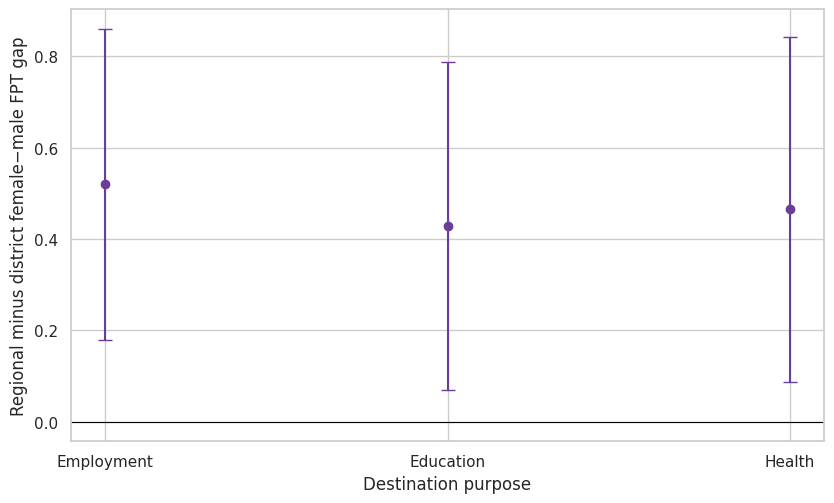

In [8]:
contrast_effects = [f"region_minus_city__{effect}" for effect in EFFECTS] + ["relative_attenuation"]
interval_rows = []
for purpose in PURPOSES:
    frame = contrasts[contrasts["purpose_group"].eq(purpose)]; point = contrast_point.set_index("purpose_group").loc[purpose]
    for effect in contrast_effects:
        values = frame[effect]
        interval_rows.append({"purpose_group": purpose, "effect": effect, "point_estimate": float(point[effect]),
                              "bootstrap_mean": float(values.mean()), "bootstrap_sd": float(values.std()),
                              "ci_lower": float(values.quantile(.025)), "ci_upper": float(values.quantile(.975))})
intervals = pd.DataFrame(interval_rows)

sim_rows = []
for effect in contrast_effects:
    wide = contrasts.pivot(index="replicate", columns="purpose_group", values=effect).reindex(columns=PURPOSES)
    point = contrast_point.set_index("purpose_group")[effect].reindex(PURPOSES); se = wide.std(axis=0).replace(0, np.nan)
    critical = float(wide.subtract(point, axis=1).abs().divide(se, axis=1).max(axis=1).quantile(.95))
    for purpose in PURPOSES:
        estimate, sd = float(point[purpose]), float(se[purpose])
        sim_rows.append({"purpose_group": purpose, "effect": effect, "max_t_critical": critical,
                         "simultaneous_ci_lower": estimate - critical * sd,
                         "simultaneous_ci_upper": estimate + critical * sd})
intervals = intervals.merge(pd.DataFrame(sim_rows), on=["purpose_group", "effect"])
intervals["simultaneously_positive"] = intervals["simultaneous_ci_lower"].gt(0)
intervals.to_csv(OUT / "paired_scope_contrast_intervals.csv", index=False)
display(intervals)

sns.set_theme(style="whitegrid", context="notebook")
plot = intervals[intervals["effect"].eq("region_minus_city__female_minus_male_total")].set_index("purpose_group").reindex(PURPOSES)
fig, axis = plt.subplots(figsize=(8.5, 5.2)); x = np.arange(len(PURPOSES)); y = plot["point_estimate"].to_numpy(float)
axis.errorbar(x, y, yerr=[y - plot["simultaneous_ci_lower"].to_numpy(float), plot["simultaneous_ci_upper"].to_numpy(float) - y],
              fmt="o", capsize=5, color="#6A3D9A")
axis.axhline(0, color="black", linewidth=.8); axis.set_xticks(x); axis.set_xticklabels([p.title() for p in PURPOSES])
axis.set(xlabel="Destination purpose", ylabel="Regional minus district female−male FPT gap")
fig.tight_layout(); fig.savefig(OUT / "figure_paired_scope_amplification.png", dpi=240, bbox_inches="tight"); plt.show()


In [9]:
thresholds = {"maximum_point_replication_error": 1e-9, "maximum_closure_error": 1e-10}
checks = {
    "gate11_dependency_valid": bool(gate11.get("gate", {}).get("gate_11_passed", False)),
    "gate12_dependency_valid": bool(gate12.get("gate", {}).get("gate_12_passed", False)),
    "both_scopes_row_stochastic": bool(all(np.allclose(s["P0"].sum(axis=1), 1, atol=1e-10) for s in scopes.values())),
    "validated_points_reproduced": bool(replication_error <= thresholds["maximum_point_replication_error"]),
    "paired_bootstrap_500_complete": bool(contrasts["replicate"].nunique() == BOOTSTRAP_REPLICATES and len(contrasts) == BOOTSTRAP_REPLICATES * len(PURPOSES)),
    "paired_results_finite": bool(np.isfinite(contrasts.select_dtypes(include="number").to_numpy()).all() and np.isfinite(intervals.select_dtypes(include="number").to_numpy()).all()),
    "decomposition_identity_valid": bool(paired_point["closure_error"].abs().max() <= thresholds["maximum_closure_error"]),
}
checks["gate_13_passed"] = bool(all(checks.values()))
report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "estimand": "paired change in female-minus-male FPT gap from Bogotá D.C.-internal to Bogotá–Region",
    "bootstrap": {"method": "shared Poisson(1) household cluster multiplier across scopes", "replicates": BOOTSTRAP_REPLICATES, "seed": RANDOM_SEED},
    "interpretation": "positive region-minus-city values indicate amplification associated with the regional scope; this is descriptive/inferential, not causal",
    "point_contrasts": json.loads(contrast_point.to_json(orient="records")),
    "intervals": json.loads(intervals.to_json(orient="records")),
    "thresholds": thresholds, "gate": checks,
}
(OUT / "gate_13.json").write_text(json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")
pd.Series(checks, name="result").to_csv(OUT / "gate_13_checks.csv")
display(pd.Series(checks, name="result"))
persistent = DRIVE_BASE / "results/gate13"; persistent.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file(): shutil.copy2(artifact, persistent / artifact.name)
print("Compuerta 13:", "APROBADA" if checks["gate_13_passed"] else "NO APROBADA")
print("Copia persistente:", persistent)


,result
gate11_dependency_valid,True
gate12_dependency_valid,True
both_scopes_row_stochastic,True
validated_points_reproduced,True
paired_bootstrap_500_complete,True
paired_results_finite,True
decomposition_identity_valid,True
gate_13_passed,True


Compuerta 13: APROBADA
Copia persistente: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate13


## Criterio de lectura

El contraste primario es

$$\Delta_{scope}=\widehat{Gap}_{Bogotá-Región}-\widehat{Gap}_{Bogotá\ D.C.}.$$

Un intervalo simultáneo completamente por encima de cero respalda que la brecha regional es mayor para esa familia de destinos. Esto no identifica un efecto causal de los municipios periféricos: los dos alcances también tienen kernels y conjuntos de oportunidades distintos.
